# Gradients through the normal operator

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FiRMLAB-Pisa/mrtoeplitz/blob/main/examples/unrolled.ipynb)

The transfer is Hermitian, so its backward pass is one more application of
itself — which is what lets it sit inside an unrolled network without the
memory a traced operator would cost.

In [1]:
try:
    import mrtoeplitz  # noqa: F401
except ImportError:
    %pip install -q "mrtoeplitz[nufft]" matplotlib finufft

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

import mrtoeplitz as mt


def phantom(n=128):
    """A Shepp-Logan phantom on an n x n grid."""
    y, x = np.mgrid[-1 : 1 : n * 1j, -1 : 1 : n * 1j]
    ellipses = [
        # value, centre x, centre y, semi-axis a, semi-axis b, degrees
        (1.0, 0.0, 0.0, 0.69, 0.92, 0),
        (-0.8, 0.0, -0.0184, 0.6624, 0.874, 0),
        (-0.2, 0.22, 0.0, 0.11, 0.31, -18),
        (-0.2, -0.22, 0.0, 0.16, 0.41, 18),
        (0.1, 0.0, 0.35, 0.21, 0.25, 0),
        (0.1, 0.0, 0.1, 0.046, 0.046, 0),
        (0.1, 0.0, -0.1, 0.046, 0.046, 0),
        (0.1, -0.08, -0.605, 0.046, 0.023, 0),
        (0.1, 0.0, -0.606, 0.023, 0.023, 0),
        (0.1, 0.06, -0.605, 0.023, 0.046, 0),
    ]
    image = np.zeros((n, n))
    for value, cx, cy, a, b, degrees in ellipses:
        angle = np.deg2rad(degrees)
        xr = (x - cx) * np.cos(angle) + (y - cy) * np.sin(angle)
        yr = -(x - cx) * np.sin(angle) + (y - cy) * np.cos(angle)
        image[(xr / a) ** 2 + (yr / b) ** 2 <= 1.0] += value
    return image


torch.manual_seed(0)
n = 64
truth = torch.as_tensor(phantom(n)).to(torch.complex64)[None, None]

angles = np.linspace(0, np.pi, 24, endpoint=False)  # deliberately undersampled
radius = np.linspace(-0.5, 0.5, 128, endpoint=False)
trajectory = np.stack(
    [np.outer(np.cos(angles), radius), np.outer(np.sin(angles), radius)], axis=-1
).astype(np.float32)

# Analytic radial weights: without them the starting image is dominated by
# the 1/|k| sampling density rather than by the object.
density = np.linalg.norm(trajectory, axis=-1).astype(np.float32)
kernel = mt.scalar_kernel(trajectory, (n, n), density=density)
measurement = kernel(truth)  # the adjoint of the data, which is what a net sees
print(kernel)

PolyphaseToeplitzKernel(rank=1, image_shape=(64, 64), components=4, compression=1.16x)


## The gradient is the operator

`A^H A` is Hermitian, so it is its own adjoint and the backward pass is one
more application of the forward one. That is written as a custom
`autograd.Function` rather than left to the tape, and it matters more than it
sounds: the lanes that make a large transfer fit — the packed Hermitian
kernels, the streamed host staging — cannot be traced at all.

In [3]:
x = truth.clone().requires_grad_(True)
loss = kernel(x).abs().square().sum()
loss.backward()
print(f"gradient flows: {tuple(x.grad.shape)}, {x.grad.dtype}")

# The operator is Hermitian, so its backward is one more application of
# itself. Checking that against what autograd actually produced:
with torch.no_grad():
    expected = 2 * kernel(kernel(truth))
print(f"backward matches a second application to "
      f"{float((x.grad - expected).norm() / expected.norm()):.1e}")

gradient flows: (1, 1, 64, 64), torch.complex64
backward matches a second application to 9.9e-08


## What the graph holds

Because backward is the operator itself, nothing about the transfer needs
saving for it.

In [4]:
def peak_graph_bytes(build):
    """Bytes of activations a backward pass has to keep alive."""
    x = truth.clone().requires_grad_(True)
    output = build(x)
    held = set()
    stack = [output.grad_fn]
    total = 0
    while stack:
        node = stack.pop()
        if node is None or id(node) in held:
            continue
        held.add(id(node))
        for tensor in getattr(node, "saved_tensors", ()):  # pragma: no branch
            total += tensor.numel() * tensor.element_size()
        stack.extend(parent for parent, _ in node.next_functions)
    return total


held = peak_graph_bytes(kernel)
print(f"one application saves {held} bytes of activations")
print(f"the transfer it would otherwise have to keep: "
      f"{kernel.storage_nbytes / 2**20:.2f} MiB")
print()
print("Backward rebuilds the product from the kernel it already holds, so an")
print("unrolled network pays for its iterates and nothing else.")

one application saves 0 bytes of activations
the transfer it would otherwise have to keep: 0.11 MiB

Backward rebuilds the product from the kernel it already holds, so an
unrolled network pays for its iterates and nothing else.


## An unrolled network

Five gradient-descent steps on the data term, each followed by a learned
convolution. The physics enters once per step, as the normal operator, and
the whole thing trains end to end.

One object is not a training set, so this is a check that gradients reach the
parameters through the operator — not a reconstruction method.

In [5]:
class Unrolled(torch.nn.Module):
    """Gradient descent on the data term, with a learned step and denoiser."""

    def __init__(self, kernel, steps=5):
        super().__init__()
        self.kernel = kernel
        self.steps = steps
        self.step_size = torch.nn.Parameter(torch.full((steps,), 0.05))
        self.denoiser = torch.nn.Conv2d(2, 2, 3, padding=1)
        torch.nn.init.zeros_(self.denoiser.weight)
        torch.nn.init.zeros_(self.denoiser.bias)

    def forward(self, adjoint):
        estimate = adjoint.clone()
        for step in range(self.steps):
            # The data term's gradient is the normal operator; this is the
            # only place the physics enters, and it is differentiable.
            residual = self.kernel(estimate) - adjoint
            estimate = estimate - self.step_size[step] * residual
            stacked = torch.cat([estimate.real, estimate.imag], dim=1)
            update = self.denoiser(stacked)
            estimate = estimate + torch.complex(update[:, :1], update[:, 1:])
        return estimate


model = Unrolled(kernel)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-3)

losses = []
for _ in range(60):
    optimizer.zero_grad()
    estimate = model(measurement)
    loss = (estimate - truth).abs().square().mean()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

print(f"loss {losses[0]:.4f} -> {losses[-1]:.4f}")
print(f"learned steps: {model.step_size.detach().numpy().round(3)}")

loss 0.0534 -> 0.0131
learned steps: [0.22  0.236 0.245 0.247 0.245]


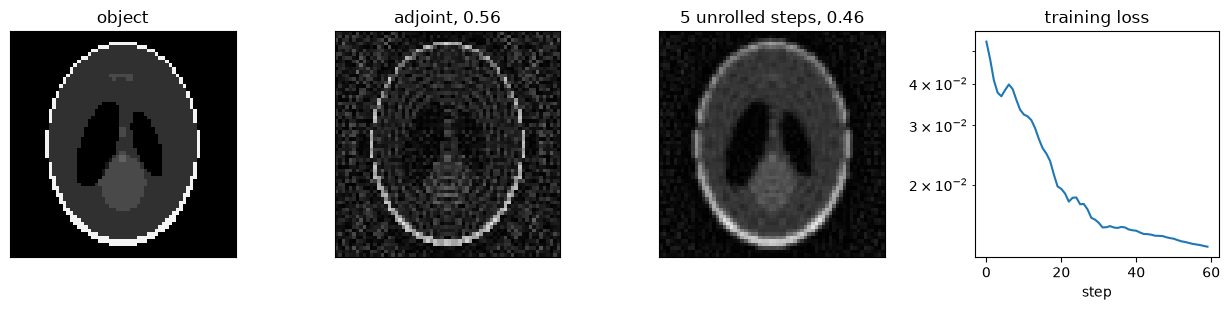

In [6]:
with torch.no_grad():
    trained = model(measurement)[0, 0].numpy()
adjoint = measurement[0, 0].numpy()
target = truth[0, 0].numpy()


def matched(estimate):
    got, want = estimate.reshape(-1), target.reshape(-1)
    scale = np.vdot(got, want) / np.vdot(got, got)
    return scale * estimate, float(
        np.linalg.norm(scale * got - want) / np.linalg.norm(want)
    )


shown_adjoint, adjoint_error = matched(adjoint)
shown_trained, trained_error = matched(trained)

fig, axes = plt.subplots(1, 4, figsize=(12.5, 3.2))
for axis, data, title in (
    (axes[0], target, "object"),
    (axes[1], shown_adjoint, f"adjoint, {adjoint_error:.2f}"),
    (axes[2], shown_trained, f"5 unrolled steps, {trained_error:.2f}"),
):
    axis.imshow(np.abs(data), cmap="gray", vmin=0, vmax=1.05)
    axis.set_title(title)
    axis.set_xticks([])
    axis.set_yticks([])
axes[3].semilogy(losses)
axes[3].set_title("training loss")
axes[3].set_xlabel("step")
fig.tight_layout()

In [7]:
# Written only when the notebook runs inside a clone, and it is what the
# README shows -- so the figure in the README is always this cell's output.
figures = Path("figures")
if figures.is_dir():
    fig.savefig(figures / "unrolled.png", dpi=110, bbox_inches="tight")